# Four-feature controlled VQ / GMVAE experiment
Input and reconstruction: F1, F2, F3, duration only. No F0 or F0 indicator. The previous manifest is loaded directly; no resampling. VQ K=16/64 with lambda=0/1; original GMVAE K=16/64; five seeds 42–46. Supervised classifier, 15-NN, and pooled K=5 k-means/full-covariance GMM references are rerun.

Edit src/configs/four_feature.py for a fresh run. The default below reloads the completed experiment. VQ retains CPU training; GMVAE uses deterministic CUDA with an algebraically equivalent, memory-efficient original ELBO. It is not the shared-w or neural-search model.

In [1]:
from pathlib import Path
import sys, json, runpy, subprocess
from dataclasses import asdict
import pandas as pd
from IPython.display import display, Markdown, Image
ROOT = Path.cwd() if (Path.cwd()/'src').exists() else Path.cwd().parent
sys.path.insert(0,str(ROOT))
CONFIG_PATH = ROOT/'src/configs/four_feature.py'
config = runpy.run_path(str(CONFIG_PATH))['CONFIG']
print('Interpreter:',sys.executable)
display(asdict(config))
# Set None for a new run after changing the configuration.
RESUME_RUN = ROOT/'outputs/four_feature/20260929_115725_f5d4e5'

Interpreter: C:\Users\46021\.conda\envs\lffl\python.exe


{'data': {'csv_path': 'metadata_vowels_acoustics.csv',
  'features': ('f1_hz', 'f2_hz', 'f3_hz', 'duration_s'),
  'n_speakers': 10,
  'speaker_ids': None,
  'seed': 2026,
  'split': (0.8, 0.1, 0.1),
  'log_features': False},
 'training_speakers': ('jvs003',
  'jvs009',
  'jvs018',
  'jvs036',
  'jvs037',
  'jvs038',
  'jvs046',
  'jvs061',
  'jvs065',
  'jvs078'),
 'heldout_count': 3,
 'hidden_dims': (128, 128),
 'embedding_dim': 8,
 'commitment': 0.25,
 'lambdas': (0.0, 1.0),
 'selection_seeds': (42, 43, 44),
 'seeds': (42, 43, 44, 45, 46),
 'baseline_seeds': (42, 43, 44),
 'selection_epochs': 40,
 'epochs': 80,
 'pretrain_epochs': 10,
 'batch_size': 512,
 'learning_rate': 0.001,
 'workers': 2,
 'threads': 1,
 'output_dir': 'outputs/four_feature',
 'codebook_pairs': ((16, 16), (64, 64)),
 'kmeans_n_init': 10,
 'gmm_n_init': 5,
 'gmm_max_iter': 300,
 'gmm_reg_covar': 1e-05,
 'reference_run': 'outputs/vq_sensitivity/20260929_011130_ec2936',
 'gmvae_model': {'hidden_dims': (128, 128),
  

In [2]:
command = [sys.executable,str(ROOT/'src/train_four_feature.py'),'--config',str(CONFIG_PATH)]
if RESUME_RUN is not None:
    command += ['--resume',str(RESUME_RUN)]
p = subprocess.Popen(command,cwd=ROOT,stdout=subprocess.PIPE,stderr=subprocess.STDOUT,text=True)
run_dir = RESUME_RUN
for line in p.stdout:
    print(line,end='')
    if line.startswith('RUN DIRECTORY: '):
        run_dir = Path(line.strip().split('RUN DIRECTORY: ',1)[1])
assert p.wait() == 0
assert (run_dir/'complete.json').exists()
display(json.loads((run_dir/'complete.json').read_text()))

COMPLETE: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\four_feature\20260929_115725_f5d4e5


{'neural_runs': 35,
 'knn_fits': 1,
 'raw_fits': 10,
 'matched_vq_initialization': True}

Report: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\four_feature\20260929_115725_f5d4e5\REPORT.md


# Four-feature VQ-VAE versus original GMVAE

## Design

Only F1, F2, F3 and duration enter input, reconstruction, cleaning and preprocessing. No F0 or missing-F0 indicator is loaded. The actual previous split manifest is loaded and copied byte-for-byte; speaker identities and token membership are unchanged. Training-only median imputation and standardization match the corresponding four old feature statistics. The manifest stores membership, not the old randomized array ordering: new arrays use manifest/source-row order, identically for all new conditions. Historical same-seed comparisons therefore do not imply identical initialization or minibatch sequences across feature dimensions.

| speaker | train | val | test_seen | test_unseen |
| --- | --- | --- | --- | --- |
| jvs003 | 3667 | 458 | 459 | 0 |
| jvs009 | 3710 | 464 | 464 | 0 |
| jvs018 | 3782 | 473 | 473 | 0 |
| jvs036 | 3696 | 462 | 462 | 0 |
| jvs037 | 3622 | 453 | 453 | 0 |
| jvs038 | 3642 | 455 | 456 | 0 |
| jvs046 | 3673 | 459 | 460 | 0 |
| jvs061 | 3702 | 463 | 463 | 0 |
| jvs065 | 3704 | 463 | 463 | 0 |
| jvs078 | 3665 | 458 | 459 | 0 |
| jvs004 | 0 | 0 | 0 | 4566 |
| jvs020 | 0 | 0 | 0 | 4631 |
| jvs086 | 0 | 0 | 0 | 4489 |

| vowel | train | val | test_seen | test_unseen |
| --- | --- | --- | --- | --- |
| a | 9017 | 1129 | 1144 | 3340 |
| e | 5201 | 652 | 686 | 1977 |
| i | 6327 | 756 | 785 | 2322 |
| o | 9610 | 1213 | 1162 | 3524 |
| u | 6708 | 858 | 835 | 2523 |

## Models and training

VQ: two 4→128 ReLU→128 ReLU→8 encoders; concatenated quantized vectors →128 ReLU→128 ReLU→4 decoder; linear 8→10 speaker head on z_s. K=16/16 or 64/64, lambda=0 or 1; seeds 42–46. Loss = feature-mean MSE + sum over branches of [mean squared codebook error + 0.25 mean squared commitment error] + lambda CE. Gradient-updated embeddings, standard straight-through h+(e-h).detach(), no EMA/reset. CE gradients enter encoder/head, not embeddings directly. Ten continuous-AE epochs and train-only 10-restart K-means initialize each branch; Adam .001, batch512, clip10, 80 fixed epochs, final checkpoint. Initial weights and minibatch sequences match across lambda; neural initial weights also match across K. No phoneme labels enter VQ training.

GMVAE is the original TwoFactorVaDE, not the shared-w or neural-grid variant: 4→128 ReLU→128 ReLU encoder, 8D diagonal-Gaussian z, symmetric nonlinear decoder; independent uniform categorical priors, with K×K diagonal Gaussian components. Component mean = global + centered phoneme effect + centered speaker effect + double-centered interaction. K=16 means 256 joint components; K=64 means 4096, unlike VQ with 2K embeddings. The original loss is reconstruction Gaussian NLL (fixed variance .1) + responsibility-weighted Gaussian KL + categorical KL + 10×mean squared centered interaction. Responsibilities are averaged over four posterior samples during training; evaluation uses 32 and marginal argmax per factor. Twenty AE epochs, sequential residual K-means initialization (10 restarts), Adam .001, batch512, clip10, up to100 epochs; validation original-objective early stopping (patience20, min_delta1e-4), best checkpoint. No speaker/phoneme supervision. All statistical settings are unchanged. Only Gaussian quadratic computations are algebraically reassociated into matrix products to avoid enormous broadcast tensors; double-precision loss/gradient equivalence tests pass. Execution uses deterministic CUDA on RTX3060 rather than the old CPU; finite-precision trajectories can differ. Reconstruction MSE uses decoder(posterior mean), as in the preceding baseline; it is not the MC training NLL.

Supervised references retain the earlier 15-NN and nonlinear dual-head classifier with two128-unit ReLU hidden layers and 8D bottleneck. Classifier optimization/validation stopping follows the old defaults above, without AE pretraining. The classifier uses both true phoneme and familiar-speaker targets; both references are supervised, not equivalent clustering methods. 15-NN is deterministic and fitted once, not presented as five independent seeds.

| method | k_phi | parameter_count |
| --- | --- | --- |
| classifier | 0 | 18319.0 |
| gmvae | 16 | 41788.0 |
| gmvae | 64 | 104092.0 |
| vq | 16 | 55918.0 |
| vq | 64 | 56686.0 |

## Compact comparison: mean ± sample SD

Lambda -1 means not applicable (original unsupervised GMVAE). Accuracy is percent. Every discrete state maps to its training-majority vowel; mappings are frozen before validation/test evaluation. Unused training states fall back to the training-majority label. Purity is descriptive test contingency purity, not a test-fitted prediction mapping. All conditions are reported; no best test lambda is selected.

| method | k_phi | lambda_s | split | seeds | phoneme_accuracy | phi_phi_nmi | phi_phi_ami | phi_phi_ari | phi_phi_purity | phi_s_nmi | s_phi_nmi | s_s_nmi | phi_active_codes | s_active_codes | phi_perplexity | s_perplexity | mse |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| gmvae | 16 | -1.0 | test_seen | 5 | 56.583 ± 2.832 | 0.272 ± 0.015 | 0.270 ± 0.016 | 0.184 ± 0.023 | 0.566 ± 0.028 | 0.086 ± 0.012 | 0.120 ± 0.046 | 0.049 ± 0.021 | 13.800 ± 1.483 | 14.000 ± 0.707 | 9.464 ± 0.746 | 6.330 ± 1.668 | 0.022 ± 0.001 |
| gmvae | 16 | -1.0 | test_unseen | 5 | 53.658 ± 3.102 | 0.255 ± 0.015 | 0.254 ± 0.015 | 0.186 ± 0.023 | 0.555 ± 0.028 | 0.083 ± 0.032 | 0.124 ± 0.051 | 0.036 ± 0.015 | 13.600 ± 2.074 | 14.200 ± 1.095 | 8.705 ± 0.596 | 5.948 ± 1.645 | 0.025 ± 0.001 |
| gmvae | 64 | -1.0 | test_seen | 5 | 59.219 ± 1.027 | 0.268 ± 0.009 | 0.263 ± 0.009 | 0.124 ± 0.017 | 0.595 ± 0.010 | 0.109 ± 0.004 | 0.175 ± 0.027 | 0.071 ± 0.011 | 33.600 ± 3.912 | 28.600 ± 8.473 | 19.284 ± 2.165 | 8.873 ± 1.567 | 0.022 ± 0.001 |
| gmvae | 64 | -1.0 | test_unseen | 5 | 54.850 ± 1.623 | 0.258 ± 0.007 | 0.257 ± 0.007 | 0.140 ± 0.025 | 0.574 ± 0.024 | 0.110 ± 0.005 | 0.194 ± 0.021 | 0.073 ± 0.008 | 35.200 ± 4.147 | 34.600 ± 8.905 | 16.582 ± 2.078 | 9.157 ± 1.932 | 0.025 ± 0.001 |
| vq | 16 | 0.0 | test_seen | 5 | 55.594 ± 10.796 | 0.228 ± 0.101 | 0.226 ± 0.101 | 0.128 ± 0.067 | 0.557 ± 0.108 | 0.081 ± 0.018 | 0.160 ± 0.101 | 0.098 ± 0.029 | 15.400 ± 0.548 | 15.600 ± 0.548 | 13.299 ± 1.177 | 13.820 ± 1.488 | 0.081 ± 0.005 |
| vq | 16 | 0.0 | test_unseen | 5 | 53.747 ± 11.506 | 0.233 ± 0.102 | 0.233 ± 0.102 | 0.140 ± 0.075 | 0.553 ± 0.116 | 0.096 ± 0.047 | 0.167 ± 0.092 | 0.095 ± 0.053 | 15.400 ± 0.548 | 15.600 ± 0.548 | 11.969 ± 1.279 | 12.334 ± 1.917 | 0.086 ± 0.004 |
| vq | 16 | 1.0 | test_seen | 5 | 61.006 ± 6.505 | 0.274 ± 0.045 | 0.271 ± 0.045 | 0.156 ± 0.034 | 0.612 ± 0.065 | 0.031 ± 0.005 | 0.118 ± 0.049 | 0.259 ± 0.004 | 15.400 ± 0.548 | 15.600 ± 0.548 | 13.432 ± 0.524 | 14.040 ± 0.812 | 0.118 ± 0.007 |
| vq | 16 | 1.0 | test_unseen | 5 | 59.285 ± 6.273 | 0.273 ± 0.030 | 0.272 ± 0.030 | 0.163 ± 0.032 | 0.603 ± 0.059 | 0.046 ± 0.017 | 0.096 ± 0.040 | 0.228 ± 0.014 | 15.800 ± 0.447 | 15.600 ± 0.548 | 12.561 ± 0.670 | 12.516 ± 0.840 | 0.126 ± 0.009 |
| vq | 64 | 0.0 | test_seen | 5 | 58.183 ± 7.084 | 0.214 ± 0.057 | 0.207 ± 0.058 | 0.053 ± 0.019 | 0.589 ± 0.071 | 0.116 ± 0.038 | 0.148 ± 0.062 | 0.103 ± 0.032 | 61.000 ± 2.000 | 61.400 ± 0.548 | 46.234 ± 5.298 | 47.520 ± 3.304 | 0.028 ± 0.001 |
| vq | 64 | 0.0 | test_unseen | 5 | 56.081 ± 6.450 | 0.214 ± 0.049 | 0.211 ± 0.049 | 0.059 ± 0.018 | 0.582 ± 0.066 | 0.100 ± 0.052 | 0.160 ± 0.045 | 0.090 ± 0.032 | 60.800 ± 1.924 | 61.200 ± 0.837 | 40.681 ± 6.241 | 43.333 ± 5.331 | 0.029 ± 0.001 |
| vq | 64 | 1.0 | test_seen | 5 | 65.017 ± 5.003 | 0.253 ± 0.028 | 0.246 ± 0.028 | 0.058 ± 0.009 | 0.655 ± 0.050 | 0.070 ± 0.007 | 0.188 ± 0.023 | 0.250 ± 0.003 | 62.800 ± 0.837 | 60.600 ± 2.881 | 51.951 ± 1.331 | 54.282 ± 3.664 | 0.049 ± 0.002 |
| vq | 64 | 1.0 | test_unseen | 5 | 59.944 ± 6.322 | 0.242 ± 0.027 | 0.239 ± 0.027 | 0.060 ± 0.010 | 0.641 ± 0.055 | 0.066 ± 0.013 | 0.175 ± 0.023 | 0.199 ± 0.005 | 63.000 ± 0.707 | 60.800 ± 2.490 | 47.393 ± 2.279 | 47.446 ± 4.700 | 0.054 ± 0.003 |

Fraction assigned to states unused in training (these use the documented majority fallback):

| method | k_phi | lambda_s | split | seeds | phi_unmapped_fraction | s_unmapped_fraction |
| --- | --- | --- | --- | --- | --- | --- |
| gmvae | 16 | -1.0 | test_seen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| gmvae | 16 | -1.0 | test_unseen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| gmvae | 64 | -1.0 | test_seen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| gmvae | 64 | -1.0 | test_unseen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| vq | 16 | 0.0 | test_seen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| vq | 16 | 0.0 | test_unseen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| vq | 16 | 1.0 | test_seen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| vq | 16 | 1.0 | test_unseen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| vq | 64 | 0.0 | test_seen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| vq | 64 | 0.0 | test_unseen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| vq | 64 | 1.0 | test_seen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |
| vq | 64 | 1.0 | test_unseen | 5 | 0.000 ± 0.000 | 0.000 ± 0.000 |

Per-feature standardized reconstruction MSE (within this four-feature experiment only):

| method | k_phi | lambda_s | split | seeds | mse_f1_hz | mse_f2_hz | mse_f3_hz | mse_duration_s |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| gmvae | 16 | -1.0 | test_seen | 5 | 0.034 ± 0.002 | 0.021 ± 0.001 | 0.021 ± 0.003 | 0.014 ± 0.002 |
| gmvae | 16 | -1.0 | test_unseen | 5 | 0.036 ± 0.001 | 0.022 ± 0.001 | 0.026 ± 0.004 | 0.015 ± 0.002 |
| gmvae | 64 | -1.0 | test_seen | 5 | 0.035 ± 0.002 | 0.022 ± 0.001 | 0.020 ± 0.003 | 0.013 ± 0.003 |
| gmvae | 64 | -1.0 | test_unseen | 5 | 0.037 ± 0.001 | 0.022 ± 0.001 | 0.026 ± 0.003 | 0.014 ± 0.003 |
| vq | 16 | 0.0 | test_seen | 5 | 0.081 ± 0.008 | 0.077 ± 0.007 | 0.079 ± 0.005 | 0.086 ± 0.002 |
| vq | 16 | 0.0 | test_unseen | 5 | 0.088 ± 0.008 | 0.081 ± 0.010 | 0.097 ± 0.007 | 0.079 ± 0.007 |
| vq | 16 | 1.0 | test_seen | 5 | 0.115 ± 0.014 | 0.113 ± 0.008 | 0.112 ± 0.007 | 0.133 ± 0.013 |
| vq | 16 | 1.0 | test_unseen | 5 | 0.119 ± 0.009 | 0.125 ± 0.010 | 0.134 ± 0.011 | 0.125 ± 0.016 |
| vq | 64 | 0.0 | test_seen | 5 | 0.028 ± 0.001 | 0.027 ± 0.003 | 0.028 ± 0.002 | 0.029 ± 0.002 |
| vq | 64 | 0.0 | test_unseen | 5 | 0.030 ± 0.002 | 0.028 ± 0.003 | 0.032 ± 0.002 | 0.027 ± 0.002 |
| vq | 64 | 1.0 | test_seen | 5 | 0.049 ± 0.004 | 0.045 ± 0.003 | 0.051 ± 0.001 | 0.052 ± 0.004 |
| vq | 64 | 1.0 | test_unseen | 5 | 0.057 ± 0.007 | 0.048 ± 0.004 | 0.062 ± 0.006 | 0.049 ± 0.004 |

Speaker classification and training-fitted speaker-code accuracy are defined only for familiar speakers:

| method | k_phi | lambda_s | seeds | speaker_classifier_accuracy | speaker_code_accuracy |
| --- | --- | --- | --- | --- | --- |
| gmvae | 16 | -1.0 | 5 | — | 15.616 ± 1.268 |
| gmvae | 64 | -1.0 | 5 | — | 17.905 ± 0.899 |
| vq | 16 | 0.0 | 5 | — | 21.578 ± 2.767 |
| vq | 16 | 1.0 | 5 | 38.825 ± 0.442 | 38.833 ± 0.273 |
| vq | 64 | 0.0 | 5 | — | 23.456 ± 3.599 |
| vq | 64 | 1.0 | 5 | 41.817 ± 0.586 | 41.834 ± 0.457 |

| method | split | seeds | phoneme_accuracy | speaker_classifier_accuracy |
| --- | --- | --- | --- | --- |
| classifier | test_seen | 5 | 80.252 ± 0.314 | 44.796 ± 0.253 |
| classifier | test_unseen | 5 | 76.711 ± 0.324 | — |
| knn | test_seen | 1 | 80.356 | 43.669 |
| knn | test_unseen | 1 | 77.057 | — |




## Paired effects

All contrasts below subtract matched seeds. Accuracy differences are percentage points; full per-seed values are in paired_effects.csv. The unsupervised VQ versus GMVAE comparison is free of explicit speaker supervision but retains different latent geometry, capacity scaling, objectives and checkpoint rules. Supervised VQ versus GMVAE is a comparison of complete learning systems, not a pure architectural effect.

| comparison | split | seeds | phoneme_accuracy | phi_phi_nmi | phi_phi_ami | phi_phi_ari | phi_s_nmi | s_phi_nmi | s_s_nmi | mse |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| K16: unsupervised VQ - GMVAE | test_seen | 5 | -0.989 ± 12.902 | -0.044 ± 0.102 | -0.044 ± 0.102 | -0.056 ± 0.080 | -0.005 ± 0.022 | 0.040 ± 0.132 | 0.049 ± 0.028 | 0.058 ± 0.005 |
| K16: unsupervised VQ - GMVAE | test_unseen | 5 | 0.089 ± 11.988 | -0.021 ± 0.100 | -0.021 ± 0.101 | -0.046 ± 0.090 | 0.012 ± 0.061 | 0.042 ± 0.132 | 0.059 ± 0.059 | 0.062 ± 0.004 |
| K64: unsupervised VQ - GMVAE | test_seen | 5 | -1.036 ± 7.916 | -0.053 ± 0.061 | -0.056 ± 0.062 | -0.071 ± 0.029 | 0.006 ± 0.037 | -0.027 ± 0.054 | 0.031 ± 0.025 | 0.006 ± 0.002 |
| K64: unsupervised VQ - GMVAE | test_unseen | 5 | 1.230 ± 6.055 | -0.045 ± 0.049 | -0.046 ± 0.049 | -0.081 ± 0.032 | -0.010 ± 0.049 | -0.033 ± 0.036 | 0.017 ± 0.025 | 0.004 ± 0.002 |
| VQ K16: lambda1 - lambda0 | test_seen | 5 | 5.412 ± 8.575 | 0.045 ± 0.078 | 0.046 ± 0.078 | 0.027 ± 0.052 | -0.050 ± 0.020 | -0.042 ± 0.074 | 0.161 ± 0.032 | 0.037 ± 0.009 |
| VQ K16: lambda1 - lambda0 | test_unseen | 5 | 5.539 ± 8.119 | 0.040 ± 0.084 | 0.040 ± 0.084 | 0.023 ± 0.056 | -0.049 ± 0.054 | -0.070 ± 0.062 | 0.132 ± 0.061 | 0.040 ± 0.010 |
| VQ K64: lambda1 - lambda0 | test_seen | 5 | 6.834 ± 6.763 | 0.039 ± 0.048 | 0.039 ± 0.049 | 0.005 ± 0.017 | -0.045 ± 0.043 | 0.040 ± 0.046 | 0.147 ± 0.033 | 0.021 ± 0.001 |
| VQ K64: lambda1 - lambda0 | test_unseen | 5 | 3.864 ± 7.850 | 0.028 ± 0.044 | 0.028 ± 0.044 | 0.001 ± 0.014 | -0.034 ± 0.059 | 0.014 ± 0.035 | 0.108 ± 0.036 | 0.025 ± 0.003 |
| gmvae lambda-1: K64 - K16 | test_seen | 5 | 2.637 ± 2.545 | -0.004 ± 0.021 | -0.007 ± 0.021 | -0.060 ± 0.030 | 0.023 ± 0.014 | 0.055 ± 0.058 | 0.023 ± 0.011 | -0.000 ± 0.001 |
| gmvae lambda-1: K64 - K16 | test_unseen | 5 | 1.192 ± 4.676 | 0.004 ± 0.021 | 0.003 ± 0.021 | -0.046 ± 0.034 | 0.027 ± 0.033 | 0.069 ± 0.056 | 0.037 ± 0.020 | 0.000 ± 0.001 |
| vq lambda0: K64 - K16 | test_seen | 5 | 2.589 ± 5.608 | -0.014 ± 0.058 | -0.019 ± 0.058 | -0.076 ± 0.051 | 0.035 ± 0.024 | -0.012 ± 0.047 | 0.005 ± 0.015 | -0.053 ± 0.004 |
| vq lambda0: K64 - K16 | test_unseen | 5 | 2.334 ± 7.419 | -0.019 ± 0.068 | -0.021 ± 0.068 | -0.082 ± 0.061 | 0.005 ± 0.022 | -0.006 ± 0.052 | -0.005 ± 0.039 | -0.057 ± 0.003 |
| vq lambda1: K64 - K16 | test_seen | 5 | 4.011 ± 3.840 | -0.020 ± 0.028 | -0.026 ± 0.028 | -0.098 ± 0.027 | 0.039 ± 0.006 | 0.070 ± 0.035 | -0.009 ± 0.006 | -0.069 ± 0.007 |
| vq lambda1: K64 - K16 | test_unseen | 5 | 0.659 ± 4.274 | -0.031 ± 0.015 | -0.033 ± 0.015 | -0.103 ± 0.024 | 0.020 ± 0.018 | 0.079 ± 0.034 | -0.029 ± 0.010 | -0.072 ± 0.011 |

## Historical five-feature comparisons

These use saved historical results, not any F0-bearing input in the new experiment. No cross-dimensional raw MSE difference is reported. Previous classifier results exist for seeds42–44 only; paired classifier contrasts therefore use those three common seeds.

| lambda_s | split | seeds | phoneme_accuracy | phi_phi_nmi | phi_phi_ami | phi_phi_ari | phi_s_nmi | s_phi_nmi | s_s_nmi |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 0.0 | test_seen | 5 | 8.430 ± 15.579 | 0.051 ± 0.105 | 0.052 ± 0.106 | 0.018 ± 0.037 | -0.010 ± 0.054 | -0.055 ± 0.124 | -0.042 ± 0.058 |
| 0.0 | test_unseen | 5 | 8.338 ± 15.178 | 0.044 ± 0.088 | 0.044 ± 0.089 | 0.016 ± 0.034 | -0.020 ± 0.065 | -0.046 ± 0.103 | -0.032 ± 0.059 |
| 1.0 | test_seen | 5 | -4.805 ± 5.450 | -0.030 ± 0.033 | -0.030 ± 0.034 | -0.009 ± 0.009 | -0.019 ± 0.017 | 0.078 ± 0.026 | -0.053 ± 0.008 |
| 1.0 | test_unseen | 5 | -7.657 ± 7.031 | -0.039 ± 0.029 | -0.039 ± 0.029 | -0.018 ± 0.008 | -0.033 ± 0.015 | 0.081 ± 0.031 | -0.015 ± 0.007 |

| method | split | seeds | phoneme_accuracy |
| --- | --- | --- | --- |
| classifier | test_seen | 3 | -1.431 ± 0.471 |
| classifier | test_unseen | 3 | -1.739 ± 0.250 |
| knn | test_seen | 1 | -1.648 |
| knn | test_unseen | 1 | -1.323 |


## Pooled raw clusterability control

Five clusters; K-means10 restarts and full-covariance GMM5 restarts, max300 iterations, reg_covar1e-5. Native unlabeled fit objectives choose restarts; training-fitted Hungarian and many-to-one mappings are frozen. No repeated F0 association analysis.

Convergence: 0/10 final raw fits flagged nonconverged; full diagnostics are saved in raw_fit_diagnostics.csv.

| method | split | seeds | phoneme_hungarian_accuracy | phoneme_accuracy | phi_phi_nmi | phi_phi_ami | phi_phi_ari |
| --- | --- | --- | --- | --- | --- | --- | --- |
| gmm | test_seen | 5 | 49.410 ± 0.138 | 49.228 ± 0.117 | 0.280 ± 0.001 | 0.279 ± 0.001 | 0.254 ± 0.001 |
| gmm | test_unseen | 5 | 51.178 ± 0.036 | 51.026 ± 0.054 | 0.302 ± 0.000 | 0.302 ± 0.000 | 0.280 ± 0.001 |
| kmeans | test_seen | 5 | 45.716 ± 0.149 | 47.047 ± 0.138 | 0.196 ± 0.001 | 0.195 ± 0.001 | 0.162 ± 0.002 |
| kmeans | test_unseen | 5 | 41.156 ± 0.184 | 42.679 ± 0.146 | 0.164 ± 0.001 | 0.163 ± 0.001 | 0.122 ± 0.002 |

Changes versus historical pooled five-feature fits:

| method | split | seeds | phoneme_hungarian_accuracy | phoneme_accuracy | phi_phi_nmi | phi_phi_ari |
| --- | --- | --- | --- | --- | --- | --- |
| gmm | test_seen | 5 | 14.215 ± 0.147 | 10.642 ± 0.118 | 0.125 ± 0.001 | 0.164 ± 0.001 |
| gmm | test_unseen | 5 | 17.022 ± 0.044 | 16.862 ± 0.054 | 0.160 ± 0.000 | 0.203 ± 0.001 |
| kmeans | test_seen | 5 | 10.299 ± 0.112 | 5.928 ± 0.121 | 0.063 ± 0.000 | 0.062 ± 0.001 |
| kmeans | test_unseen | 5 | 7.633 ± 0.154 | 4.323 ± 0.131 | 0.038 ± 0.000 | 0.033 ± 0.001 |

## Interpretation and limits

At VQ K=16, speaker supervision changes phoneme accuracy by +5.41 pp seen / +5.54 pp unseen. Phoneme NMI changes by +0.045 / +0.040; speaker contamination NMI changes by -0.050 / -0.049.

At VQ K=64, speaker supervision changes phoneme accuracy by +6.83 pp seen / +3.86 pp unseen. Phoneme NMI changes by +0.039 / +0.028; speaker contamination NMI changes by -0.045 / -0.034.

More active states, lower MSE and higher majority accuracy are not by themselves categorical discovery. NMI/AMI/ARI depend on partition granularity; examine them jointly with both cross-factor associations. GMVAE can reconstruct through continuous z without its intended categories aligning to labels, unlike VQ reconstruction through discrete vectors. The GMVAE factor names are intended roles and its residual initialization is asymmetric; no test-based axis swapping is performed. Five optimization seeds on one fixed speaker sample do not estimate speaker-population uncertainty; familiar-speaker splits are tokens, not held-out utterances. Both test sets were examined in preceding experiments: these are controlled exploratory comparisons, not a fresh confirmatory holdout.

## Reproduction

`python src/train_four_feature.py --config src/configs/four_feature.py`; add `--resume RUN_DIRECTORY` to reuse a matching plan. The notebook src/train_four_feature.ipynb runs the same CLI and report. All configurations, seeds, source snapshots, split manifest, preprocessing, model checkpoints, curves, predictions, frozen mappings, contingencies, occupancy and per-feature errors are retained. GMVAE device is explicit in the config. First-seed curves/occupancy plots are shown as examples; numeric histories/diagnostics exist for every run.

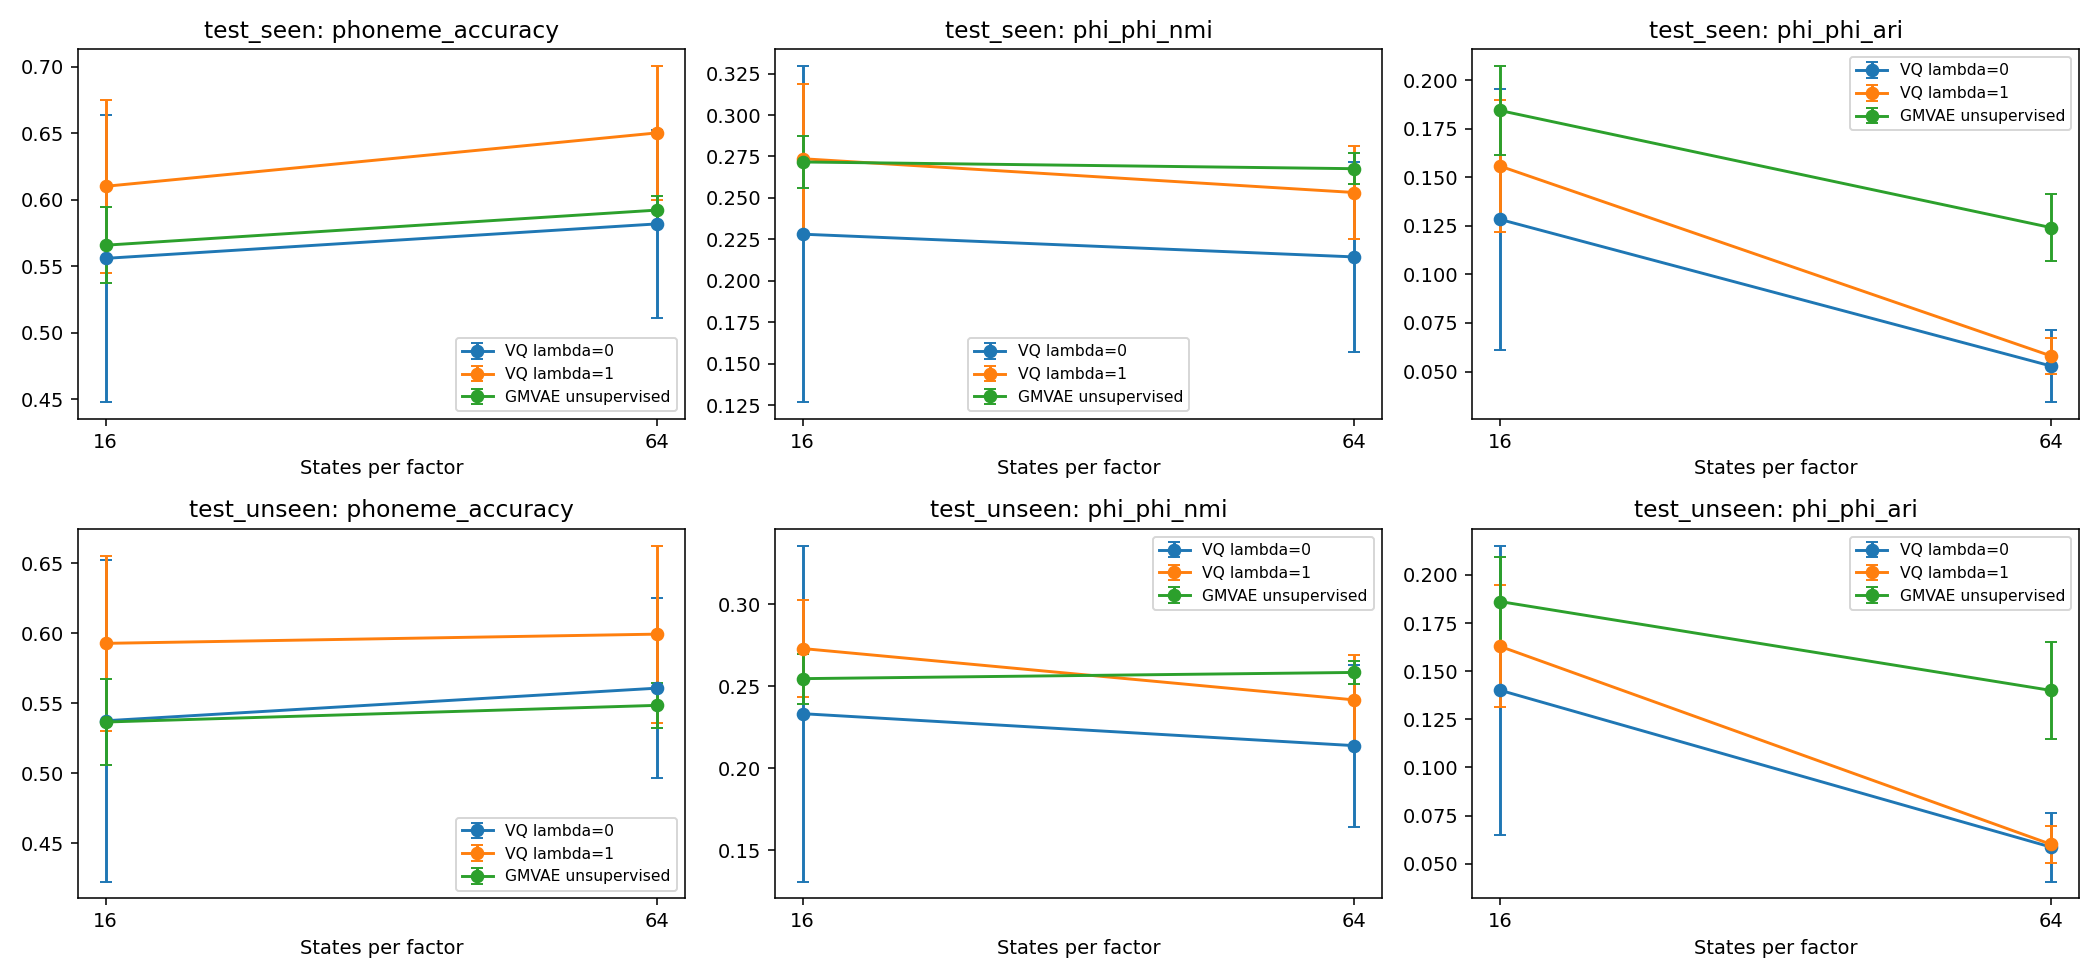

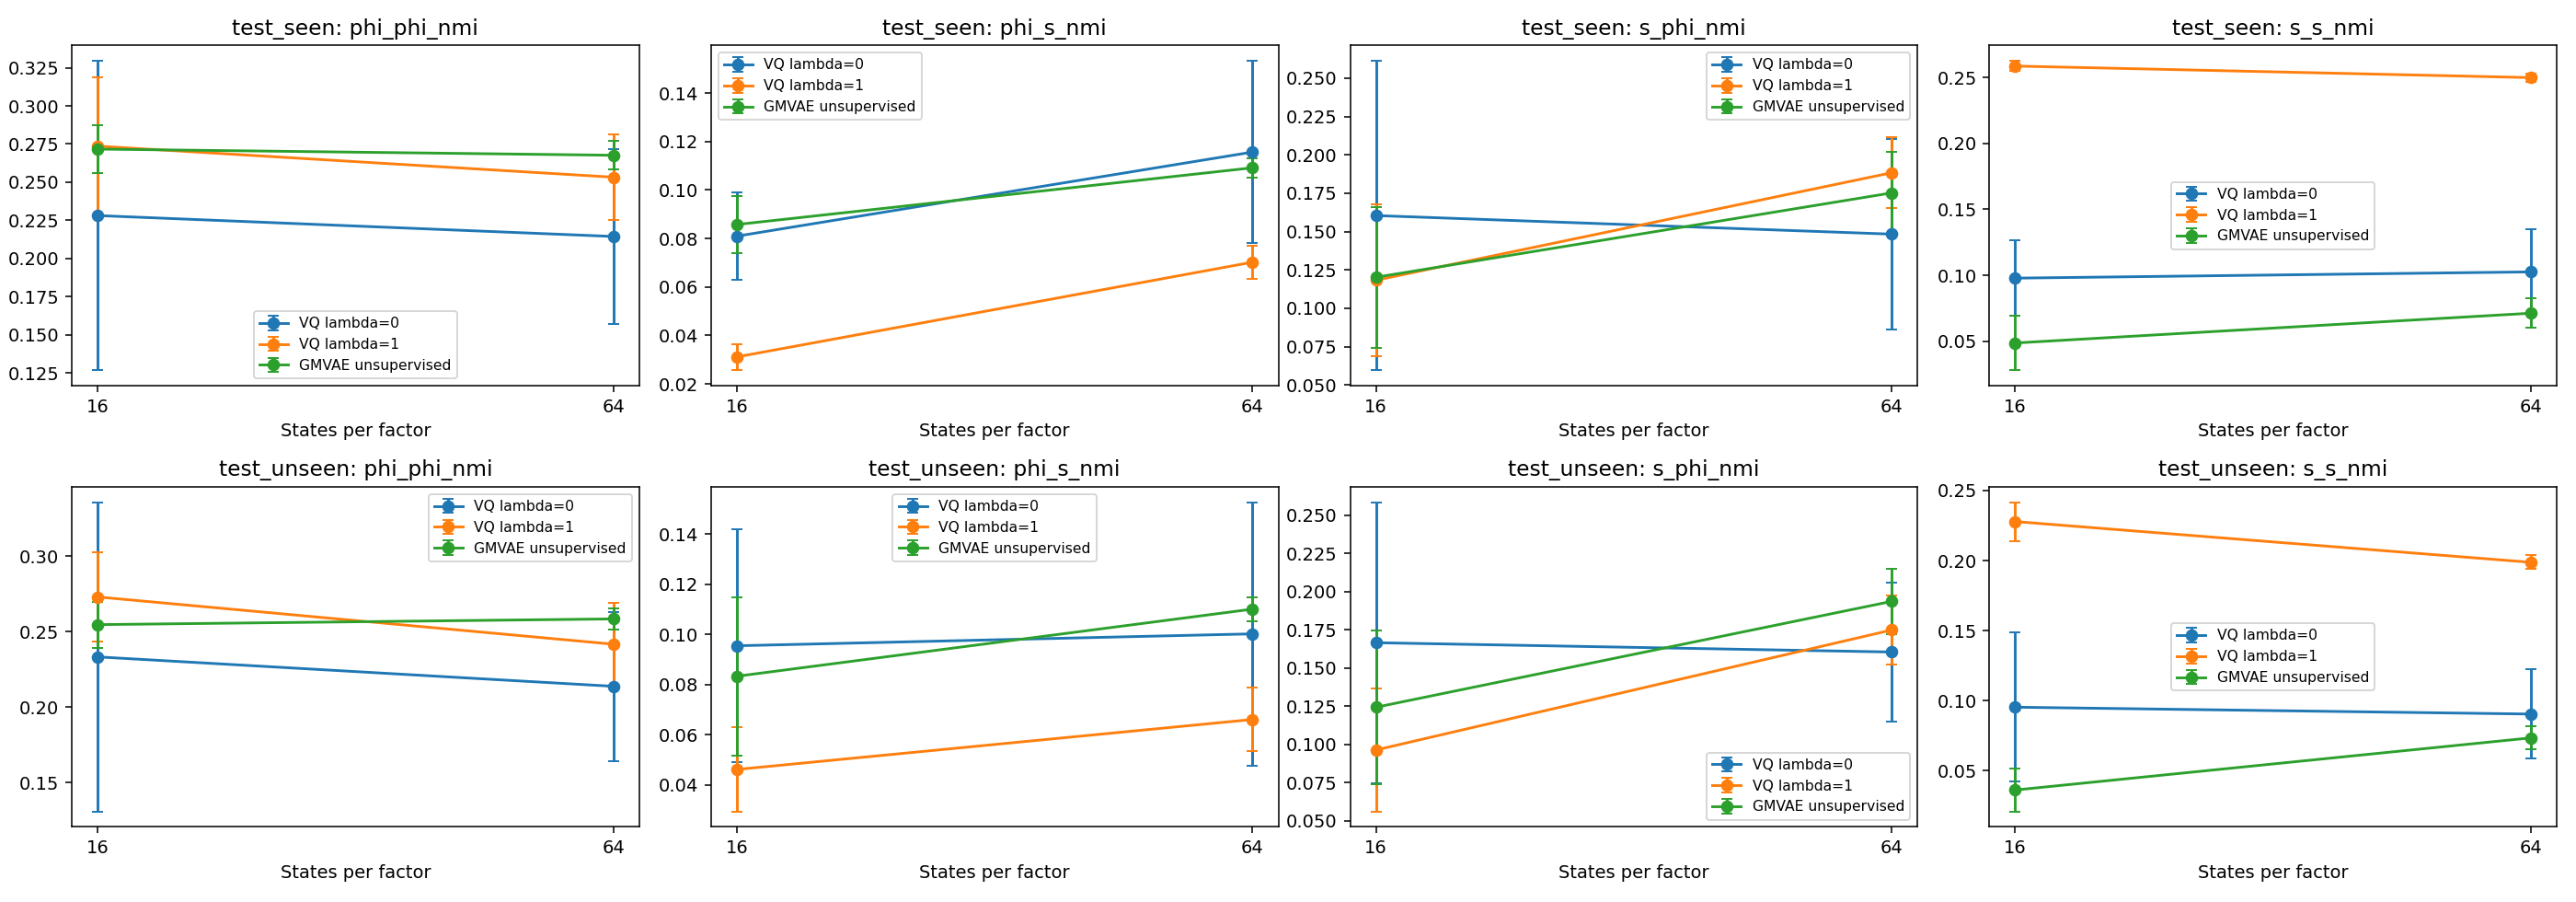

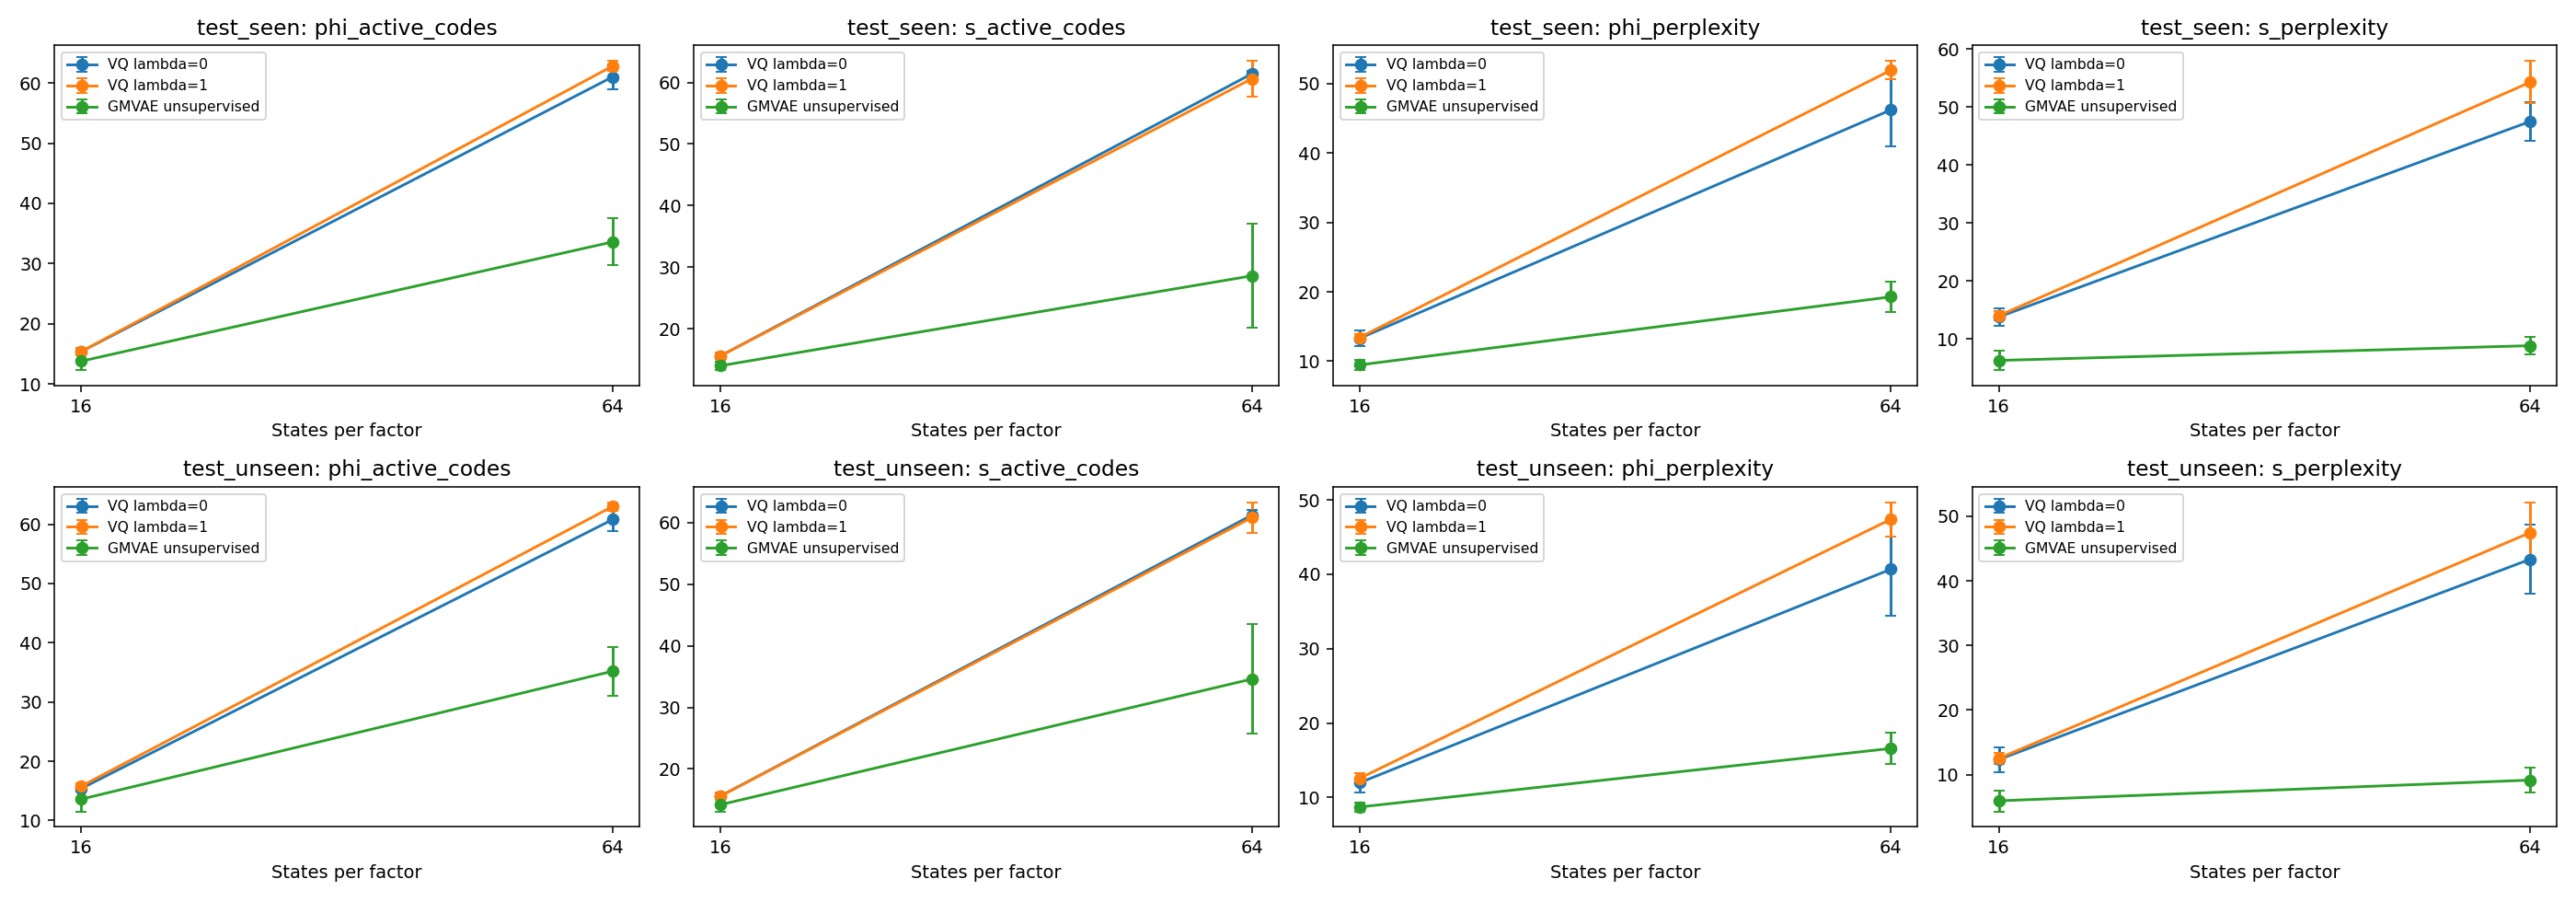

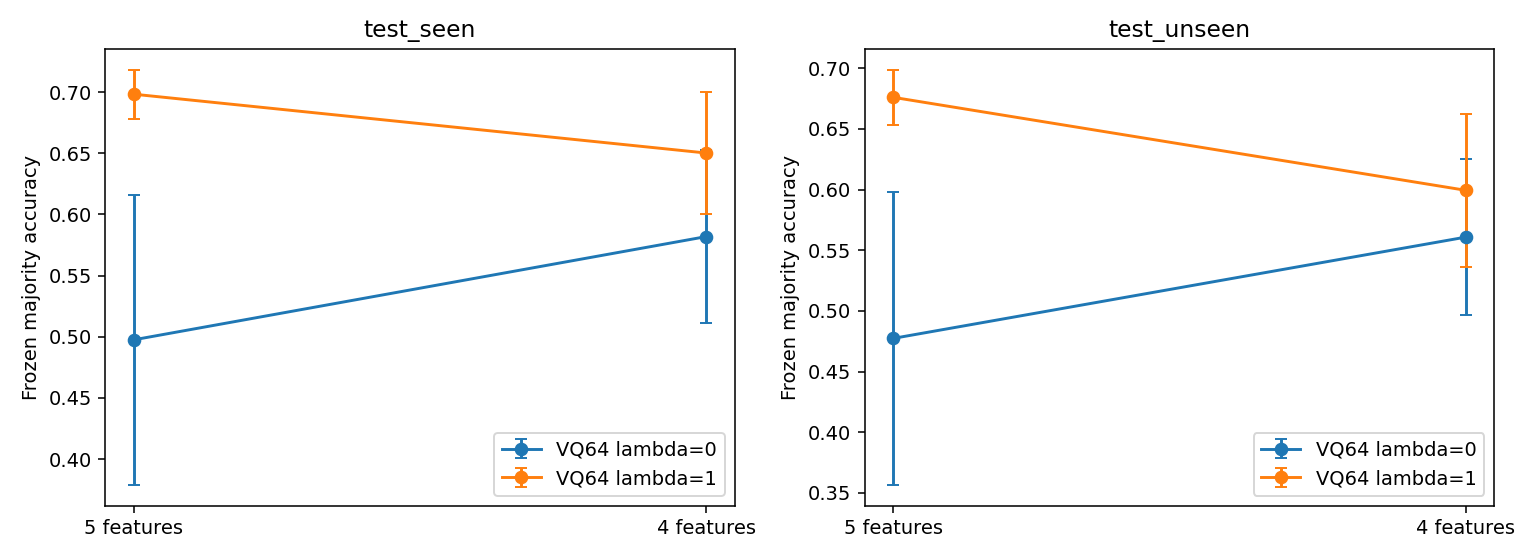

,seed,split,comparison,phoneme_accuracy,phi_phi_nmi,phi_phi_ami,phi_phi_ari,phi_s_nmi,s_phi_nmi,s_s_nmi,mse
0,42,test_seen,VQ K16: lambda1 - lambda0,0.054206,0.012885,0.012950,0.019195,-0.040381,0.017353,0.156638,0.050825
1,42,test_unseen,VQ K16: lambda1 - lambda0,0.088119,0.011646,0.011690,0.005840,0.002812,-0.034617,0.101795,0.055337
2,43,test_seen,VQ K16: lambda1 - lambda0,0.183651,0.148751,0.149201,0.104586,-0.078480,-0.121043,0.192747,0.030997
3,43,test_unseen,VQ K16: lambda1 - lambda0,0.152638,0.128429,0.128538,0.097107,-0.133578,-0.113826,0.201262,0.030280
4,44,test_seen,VQ K16: lambda1 - lambda0,0.066999,0.095766,0.096088,0.038423,-0.024934,-0.106769,0.115135,0.028854
...,...,...,...,...,...,...,...,...,...,...,...
65,44,test_unseen,gmvae lambda-1: K64 - K16,0.007014,0.001110,0.000106,-0.078058,0.064945,0.147610,0.045613,-0.000817
66,45,test_seen,gmvae lambda-1: K64 - K16,0.011275,-0.039453,-0.041657,-0.095409,0.012810,-0.010921,0.014495,0.000480
67,45,test_unseen,gmvae lambda-1: K64 - K16,-0.049467,-0.030047,-0.030821,-0.085291,0.017598,-0.003799,0.031334,0.000643
68,46,test_seen,gmvae lambda-1: K64 - K16,0.038595,0.007923,0.005714,-0.046832,0.031886,0.024938,0.012472,-0.001240


,seed,split,lambda_s,comparison,phoneme_accuracy,phi_phi_nmi,phi_phi_ami,phi_phi_ari,phi_s_nmi,s_phi_nmi,s_s_nmi
0,42,test_seen,0.0,VQ64: four features - five features,0.274935,0.183130,0.184419,0.060150,-0.018676,-0.204522,-0.053014
1,42,test_unseen,0.0,VQ64: four features - five features,0.263919,0.154948,0.155320,0.055730,-0.037492,-0.170239,-0.040624
2,42,test_seen,1.0,VQ64: four features - five features,0.013010,0.010920,0.010953,0.003890,-0.039496,0.054619,-0.053473
3,42,test_unseen,1.0,VQ64: four features - five features,-0.003580,-0.009600,-0.009628,-0.010816,-0.044845,0.066935,-0.010607
4,43,test_seen,0.0,VQ64: four features - five features,-0.057676,-0.019896,-0.019833,-0.019722,0.038576,-0.009332,-0.105657
5,43,test_unseen,0.0,VQ64: four features - five features,-0.061157,-0.024007,-0.024027,-0.019597,0.057672,-0.006659,-0.102494
6,43,test_seen,1.0,VQ64: four features - five features,-0.018864,-0.016879,-0.017004,-0.006326,-0.032967,0.053174,-0.051178
7,43,test_unseen,1.0,VQ64: four features - five features,-0.023455,-0.030533,-0.030575,-0.019983,-0.052147,0.044805,-0.005586
8,44,test_seen,0.0,VQ64: four features - five features,-0.057025,-0.063231,-0.063695,-0.011250,-0.091959,0.057008,0.048497
9,44,test_unseen,0.0,VQ64: four features - five features,-0.042160,-0.052615,-0.052725,-0.014309,-0.098354,0.052419,0.062047


In [3]:
from src.four_feature_report import make_four_report
report = make_four_report(run_dir)
display(Markdown('\n'.join(line for line in report.read_text(encoding='utf-8').splitlines() if not line.startswith('!['))))
for name in ('performance','factorization','usage','feature_removal'):
    display(Image(filename=str(run_dir/'figures'/f'{name}.png')))
display(pd.read_csv(run_dir/'paired_effects.csv'))
display(pd.read_csv(run_dir/'historical_vq_effects.csv'))

In [4]:
import numpy as np
from threadpoolctl import threadpool_limits
from src.four_feature_data import prepare_four_feature_data
from src.four_feature_training import load_four
from src.four_feature_metrics import predict_four
from src.training import seed_everything
data = prepare_four_feature_data(config)
assert 'f0_median_hz' not in data.frame
seed_everything(42,config.threads)
for name in ('vq_K64_lambda_1_seed_42','gmvae_K64_seed_42'):
    trial = run_dir/'trials'/name
    model, info = load_four(config,trial)
    if info['method']=='gmvae':
        model.to(config.gmvae_device)
    with threadpool_limits(config.threads):
        out = predict_four(model,info['method'],data.x['test_unseen'],42)
    saved = np.load(trial/'test_unseen_predictions.npz')
    for key in ('k_phi','k_s','reconstruction'):
        np.testing.assert_array_equal(out[key],saved[key])
trained = pd.DataFrame(json.loads((run_dir/'trained.json').read_text()))
vq = trained[trained.method.eq('vq')]
assert vq.groupby(['k_phi','seed']).initial_state_sha256.nunique().eq(1).all()
assert vq.groupby('seed').initial_neural_sha256.nunique().eq(1).all()
assert vq.groupby('seed').minibatch_order_sha256.nunique().eq(1).all()
assert (run_dir/'split_manifest.csv').read_bytes() == (ROOT/config.reference_run/'split_manifest.csv').read_bytes()
print('Exact VQ/GMVAE checkpoint reproduction, manifest identity and matched VQ initialization/minibatches verified.')

C:\Users\46021\.conda\envs\lffl\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Exact VQ/GMVAE checkpoint reproduction, manifest identity and matched VQ initialization/minibatches verified.
